# KP-MoSeq Sniffing Analysis — Fiber Photometry

Same FP preprocessing pipeline as the manual-annotation notebook, but behaviour is sourced from KP-MoSeq syllable 1 (sniffing) instead of EthoVision zones.

In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re
import os

# ----------------------------------------------------------
# Configuration
# ----------------------------------------------------------
main_dir   = Path(".").resolve()
#timepoints = ["Preinduction", "W1", "W2"]
timepoints = ["Preinduction"]

video_fps = 50.0
fp_fps    = 50.0

SNIFFING_SYLLABLE = 1   # KP-MoSeq syllable number for sniffing
SNIFFING_LABEL    = "Sniffing"

figures_main_dir = main_dir / "Figures_KPMoSeq"
figures_main_dir.mkdir(parents=True, exist_ok=True)

# ----------------------------------------------------------
# Genotype lookup
# ----------------------------------------------------------
def _mouse_genotype_tag(mouse_id: str):
    id_clean = mouse_id.strip()
    if id_clean in {"588", "590", "566", "580", "533", "541"}:
        return "NE"
    return None

# ----------------------------------------------------------
# Read ethovision export: returns fp_id and mouse_id
# ----------------------------------------------------------
def _read_export_and_get_fp_and_mouse_id(xl_path: Path):
    df = pd.read_excel(xl_path, header=None)
    key_col = df.iloc[:, 0].astype(str).str.strip().str.lower()

    match_fp = df[key_col == "fp file"]
    if match_fp.empty:
        raise ValueError(f"'FP file' not found in {xl_path.name}")
    fp_id = str(df.iloc[match_fp.index[0], 1]).strip()

    match_id = df[key_col == "id"]
    if match_id.empty:
        raise ValueError(f"'ID' row not found in {xl_path.name}")
    mouse_id = str(df.iloc[match_id.index[0], 1]).strip()

    return fp_id, mouse_id

# ----------------------------------------------------------
# Extract trial condition from ethovision metadata
# ----------------------------------------------------------
def _extract_condition(eth_path: Path) -> str:
    raw = pd.read_excel(eth_path, header=None, nrows=50, engine="openpyxl")
    for i in range(len(raw)):
        if str(raw.iloc[i, 0]).strip() == "Condition":
            cond = str(raw.iloc[i, 1]).strip().capitalize()
            if cond in {"Hab", "Social", "Novel"}:
                return cond
            return cond
    return "Unknown"

# ----------------------------------------------------------
# Find FP CSV and timestamp CSV
# ----------------------------------------------------------
def _find_fp_and_timestamp_files(fp_folder: Path, fp_id: str):
    fp_csv = fp_folder / f"{fp_id}.csv"
    if not fp_csv.exists():
        raise FileNotFoundError(f"FP CSV not found: {fp_csv}")

    ts_csv = None
    for p in fp_folder.glob("*.csv"):
        if "time" in p.name.lower() or "timestamp" in p.name.lower():
            directory, filename = os.path.split(p)
            clean_name = filename.lstrip("._") if filename.startswith("._") else filename
            ts_csv = Path(directory) / clean_name
            break
    if ts_csv is None:
        raise FileNotFoundError(f"No timestamp CSV found in {fp_folder}")
    return fp_csv, ts_csv

# ----------------------------------------------------------
# Find KP-MoSeq CSV in the FP folder
# ----------------------------------------------------------
def _find_kpmoseq_file(fp_folder: Path) -> Path:
    matches = list(fp_folder.glob("*superanimal*animal0.csv"))
    if not matches:
        raise FileNotFoundError(f"No KP-MoSeq CSV (*superanimal*animal0.csv) in {fp_folder}")
    return matches[0]

# ----------------------------------------------------------
# Build sniffing ethogram from KP-MoSeq dataframe
# (each row = 1 video frame at video_fps)
# ----------------------------------------------------------
def _kpmoseq_sniffing_ethogram(kp_df: pd.DataFrame, fps: float) -> pd.DataFrame:
    sniff_mask = (kp_df["syllable"] == SNIFFING_SYLLABLE).values
    time_vec   = np.arange(len(kp_df)) / fps

    segments = []
    diff = np.diff(np.r_[0, sniff_mask.astype(int), 0])
    starts = np.where(diff ==  1)[0]
    ends   = np.where(diff == -1)[0]

    for s, e in zip(starts, ends):
        t_start = float(time_vec[s])
        t_end   = float(time_vec[e - 1]) + 1.0 / fps  # inclusive last frame
        segments.append({
            "Behavior":     SNIFFING_LABEL,
            "Start_time_s": t_start,
            "End_time_s":   t_end,
            "Duration_s":   t_end - t_start
        })
    return pd.DataFrame(segments)

# ----------------------------------------------------------
# Map sniffing timeline onto FP time vector
# ----------------------------------------------------------
def map_sniffing_to_time_vector(time_vector, sniffing_timeline):
    behavior_at_time = np.array(["Other"] * len(time_vector), dtype=object)
    for _, row in sniffing_timeline.iterrows():
        mask = (time_vector >= row["Start_time_s"]) & (time_vector < row["End_time_s"])
        behavior_at_time[mask] = row["Behavior"]
    return behavior_at_time

# ----------------------------------------------------------
# Timestamp-based FP windowing helpers
# ----------------------------------------------------------
def _coerce_bool_col(series):
    if series.dtype == bool:
        return series
    if pd.api.types.is_numeric_dtype(series):
        return (series.astype(float) > 0).astype(bool)
    low = series.astype(str).str.strip().str.lower()
    return low.isin(["true", "1", "t", "yes", "y"])

def _get_video_window(ts: pd.DataFrame):
    tcol  = next(c for c in ts.columns if "time" in c.lower())
    t     = pd.to_numeric(ts[tcol], errors="coerce")
    scol  = next((c for c in ts.columns if "digital" in c.lower() or "state" in c.lower()), None)

    if scol is None:
        return float(t.iloc[0]), float(t.iloc[-1])

    state = _coerce_bool_col(ts[scol])
    if state.sum() == 0 or (~state).sum() == 0:
        return float(t.iloc[0]), float(t.iloc[-1])

    try:
        video_start = float(t[state].iloc[0])
        video_stop  = float(t[~state].iloc[0])
        if video_stop > video_start:
            return video_start, video_stop
    except Exception:
        pass
    return float(t.iloc[0]), float(t.iloc[-1])

def _build_time_vector_from_fp(fp_df):
    if "SystemTimestamp" in fp_df.columns:
        ts = pd.to_numeric(fp_df["SystemTimestamp"], errors="coerce")
        if ts.notna().sum() > len(ts) * 0.8:
            return ts.to_numpy()
    return np.arange(len(fp_df)) / fp_fps

def _snap_down_index(t, target):
    return max(0, np.searchsorted(t, target, side="right") - 1)

def _trim_fp_to_window(fp_df, start, stop):
    tt = _build_time_vector_from_fp(fp_df)
    n  = min(len(tt), len(fp_df))
    tt, fp_df = tt[:n], fp_df.iloc[:n]
    i0 = _snap_down_index(tt, start)
    i1 = _snap_down_index(tt, stop)
    out = fp_df.iloc[i0:i1+1].copy()
    out["Time_video"] = tt[i0:i1+1] - tt[i0]
    return out

def _extract_led_traces(fp_trim, chan):
    iso   = fp_trim.loc[fp_trim["LedState"] == 1, ["Time_video", chan]].rename(columns={chan: f"{chan}_iso415"})
    gcamp = fp_trim.loc[fp_trim["LedState"] == 2, ["Time_video", chan]].rename(columns={chan: f"{chan}_gcamp470"})
    return iso.reset_index(drop=True), gcamp.reset_index(drop=True)

# ----------------------------------------------------------
# Plot: LED traces + KP-MoSeq sniffing ethogram
# ----------------------------------------------------------
def _plot_trial_sniffing(fp_trim, sniffing_timeline, out_png, title_prefix):
    fig, axes = plt.subplots(3, 1, figsize=(12, 8), sharex=True,
                             gridspec_kw={"height_ratios": [2, 2, 1]})
    chan = "G0" if "G0" in fp_trim.columns else next(
        c for c in fp_trim.columns
        if pd.api.types.is_numeric_dtype(fp_trim[c])
        and c not in {"LedState", "SystemTimestamp", "Time_video", "Timestamp"}
    )
    fp1 = fp_trim[fp_trim["LedState"] == 1]
    axes[0].plot(fp1["Time_video"], fp1[chan], linewidth=0.8, color="gray")
    axes[0].set_title(f"{title_prefix}: LED 1 (isosbestic)")
    axes[0].grid(True)

    fp2 = fp_trim[fp_trim["LedState"] == 2]
    axes[1].plot(fp2["Time_video"], fp2[chan], linewidth=0.8, color="green")
    axes[1].set_title(f"{title_prefix}: LED 2 (GCaMP)")
    axes[1].grid(True)

    for _, row in sniffing_timeline.iterrows():
        axes[2].barh(0, row["Duration_s"], left=row["Start_time_s"],
                     height=0.6, color="#E41A1C")
    axes[2].set_yticks([0])
    axes[2].set_yticklabels([SNIFFING_LABEL])
    axes[2].invert_yaxis()
    axes[2].set_xlabel("Time (s)")
    axes[2].set_title("KP-MoSeq sniffing ethogram (syllable 1)")

    plt.tight_layout()
    plt.savefig(out_png, dpi=200)
    plt.close(fig)
    print(f"  Saved: {out_png.name}")


# Data loading

For each ethovision export file: read animal ID + FP folder ID, load the FP trace, load the KP-MoSeq CSV from the same FP folder, and build the sniffing ethogram.

In [2]:
fp_traces = {}

for tp in timepoints:
    print(f"\n=== Processing timepoint: {tp} ===")
    tp_dir     = main_dir / tp
    export_dir = tp_dir / "Export files"

    fig_dir_raw = figures_main_dir / tp / "Raw_traces_ethograms"
    fig_dir_raw.mkdir(parents=True, exist_ok=True)

    trial_files = sorted(export_dir.glob("Raw data-*.xlsx"))
    if not trial_files:
        print(f"[WARN] No Raw data-*.xlsx files in {export_dir}")
        continue

    for eth_path in trial_files:
        try:
            condition = _extract_condition(eth_path)
            fp_id, mouse_id = _read_export_and_get_fp_and_mouse_id(eth_path)
            geno = _mouse_genotype_tag(mouse_id)

            fp_folder = tp_dir / fp_id

            # --- FP trace ---
            fp_csv, ts_csv = _find_fp_and_timestamp_files(fp_folder, fp_id)
            fp = pd.read_csv(fp_csv, encoding="utf-8")
            fp = fp[fp["LedState"].isin([1, 2])]

            ts = pd.read_csv(ts_csv, encoding="utf-8")
            video_start, video_stop = _get_video_window(ts)
            fp_trim = _trim_fp_to_window(fp, video_start, video_stop)

            chan = "G0" if "G0" in fp_trim.columns else next(
                c for c in fp_trim.columns
                if pd.api.types.is_numeric_dtype(fp_trim[c])
                and c not in {"LedState", "SystemTimestamp", "Time_video", "Timestamp"}
            )
            iso_df, gcamp_df = _extract_led_traces(fp_trim, chan)

            # --- KP-MoSeq sniffing ---
            kp_path  = _find_kpmoseq_file(fp_folder)
            kp_df    = pd.read_csv(kp_path)
            sniffing_timeline = _kpmoseq_sniffing_ethogram(kp_df, video_fps)

            # --- Key / labels ---
            trial_stub  = eth_path.stem.replace("Raw data-", "").replace(" ", "_")
            mouse_label = f"ID{mouse_id}" + (f"_{geno}" if geno else "")
            file_stub   = f"{mouse_label}__{fp_id}__{trial_stub}"
            trial_key   = f"{tp}__{file_stub}"

            fp_traces[trial_key] = {
                "iso":       iso_df,
                "gcamp":     gcamp_df,
                "mouse_id":  mouse_id,
                "genotype":  geno,
                "timeline":  sniffing_timeline,   # KP-MoSeq sniffing segments
                "kp_df":     kp_df,
                "condition": condition,
                "week":      tp,
            }

            # --- Figure per trial ---
            fig_dir_tp_cond = figures_main_dir / tp / condition / "Raw_traces_ethograms"
            fig_dir_tp_cond.mkdir(parents=True, exist_ok=True)
            out_png = fig_dir_tp_cond / f"{file_stub}_sniffing.png"
            _plot_trial_sniffing(fp_trim, sniffing_timeline, out_png,
                                 title_prefix=f"{mouse_label} | {fp_id} | {trial_stub}")

            print(f"  ✔ {eth_path.name} | sniffing bouts: {len(sniffing_timeline)}")

        except Exception as e:
            print(f"[WARN] [{tp}] {eth_path.name}: {e}")

print(f"\nLoaded {len(fp_traces)} trials.")



=== Processing timepoint: Preinduction ===
  Saved: ID588_NE__3CT_FP0_3__3CT_Preinduction_C3-Trial_____1_sniffing.png
  ✔ Raw data-3CT_Preinduction_C3-Trial     1.xlsx | sniffing bouts: 10
  Saved: ID588_NE__3CT_FP1_3__3CT_Preinduction_C3-Trial_____3_sniffing.png
  ✔ Raw data-3CT_Preinduction_C3-Trial     3.xlsx | sniffing bouts: 19
  Saved: ID588_NE__3CT_FP2_3__3CT_Preinduction_C3-Trial_____4_sniffing.png
  ✔ Raw data-3CT_Preinduction_C3-Trial     4.xlsx | sniffing bouts: 15
  Saved: ID590_NE__3CT_FP3_3__3CT_Preinduction_C3-Trial_____5_sniffing.png
  ✔ Raw data-3CT_Preinduction_C3-Trial     5.xlsx | sniffing bouts: 11
  Saved: ID590_NE__3CT_FP4_3__3CT_Preinduction_C3-Trial_____6_sniffing.png
  ✔ Raw data-3CT_Preinduction_C3-Trial     6.xlsx | sniffing bouts: 18
  Saved: ID590_NE__3CT_FP5_3__3CT_Preinduction_C3-Trial_____7_sniffing.png
  ✔ Raw data-3CT_Preinduction_C3-Trial     7.xlsx | sniffing bouts: 18
[WARN] [Preinduction] Raw data-3CT_Preinduction_C3-Trial     8.xlsx: FP CSV not 

In [3]:
# Quick inspection
first_key = next(iter(fp_traces))
print("First key:", first_key)
print("Sniffing timeline:")
print(fp_traces[first_key]["timeline"].head(10))
print("\nISO trace:")
print(fp_traces[first_key]["iso"].head())


First key: Preinduction__ID588_NE__3CT_FP0_3__3CT_Preinduction_C3-Trial_____1
Sniffing timeline:
   Behavior  Start_time_s  End_time_s  Duration_s
0  Sniffing         27.72       29.74        2.02
1  Sniffing         34.94       37.16        2.22
2  Sniffing         44.86       47.60        2.74
3  Sniffing         48.68       50.56        1.88
4  Sniffing         79.24       79.96        0.72
5  Sniffing        129.00      131.14        2.14
6  Sniffing        131.44      131.90        0.46
7  Sniffing        260.08      260.40        0.32
8  Sniffing        276.72      277.44        0.72
9  Sniffing        290.56      290.88        0.32

ISO trace:
   Time_video  G0_iso415
0        0.02   0.023734
1        0.06   0.023767
2        0.10   0.023771
3        0.14   0.023754
4        0.18   0.023724


# FP Preprocessing
## Step 1 – Coregister ISO and GCaMP

In [4]:
def coregister_iso_gcamp(trial_traces: dict) -> pd.DataFrame:
    iso   = trial_traces["iso"].copy()
    gcamp = trial_traces["gcamp"].copy()

    iso_col   = [c for c in iso.columns   if c != "Time_video"][0]
    gcamp_col = [c for c in gcamp.columns if c != "Time_video"][0]

    n = min(len(iso), len(gcamp))
    iso   = iso.iloc[:n].reset_index(drop=True)
    gcamp = gcamp.iloc[:n].reset_index(drop=True)

    time_main = (gcamp["Time_video"].values
                 if gcamp["Time_video"].iloc[0] <= iso["Time_video"].iloc[0]
                 else iso["Time_video"].values)

    return pd.DataFrame({
        "Time_video": time_main,
        "iso415":    iso[iso_col].values,
        "gcamp470":  gcamp[gcamp_col].values,
    })

coregistered_traces = {}
for tp in timepoints:
    for k in [k for k in fp_traces if k.startswith(f"{tp}__")]:
        try:
            coregistered_traces[k] = coregister_iso_gcamp(fp_traces[k])
        except Exception as e:
            print(f"[WARN] Coregister {k}: {e}")

print(f"Coregistered {len(coregistered_traces)} trials.")
print(coregistered_traces[next(iter(coregistered_traces))].head())


Coregistered 17 trials.
   Time_video    iso415  gcamp470
0        0.00  0.023734  0.031838
1        0.04  0.023767  0.031902
2        0.08  0.023771  0.031949
3        0.12  0.023754  0.032045
4        0.16  0.023724  0.032054


## Step 2 – Lowpass filtering (10 Hz cutoff)

In [5]:
from scipy.signal import butter, filtfilt

sampling_rate = 50
b, a = butter(2, 10, btype="low", fs=sampling_rate)

for key, df in coregistered_traces.items():
    df["gcamp_denoised"] = filtfilt(b, a, df["gcamp470"].values)
    df["iso_denoised"]   = filtfilt(b, a, df["iso415"].values)

first_key = next(iter(coregistered_traces))
print("Columns after denoising:", list(coregistered_traces[first_key].columns))


Columns after denoising: ['Time_video', 'iso415', 'gcamp470', 'gcamp_denoised', 'iso_denoised']


## Step 3 – Bleach correction (double exponential + Photometrics motion correction)

In [6]:
from scipy.optimize import curve_fit

def double_exponential(t, const, amp_fast, amp_slow, tau_slow, tau_multiplier):
    tau_fast = tau_slow * tau_multiplier
    return const + amp_slow * np.exp(-t / tau_slow) + amp_fast * np.exp(-t / tau_fast)

for trial_key, df in coregistered_traces.items():
    time_seconds = df["Time_video"].values

    # ---- GCaMP double-exp fit ----
    max_g = np.max(df["gcamp_denoised"])
    p0    = [max_g/2, max_g/4, max_g/4, 3600, 0.1]
    bnds  = ([0,0,0,600,0], [max_g, max_g, max_g, 36000, 1])
    try:
        gcamp_params, _ = curve_fit(double_exponential, time_seconds,
                                    df["gcamp_denoised"], p0=p0, bounds=bnds, maxfev=5000)
        df["gcamp_expfit_walton"] = double_exponential(time_seconds, *gcamp_params)
    except Exception as e:
        print(f"[WARN] GCaMP fit {trial_key}: {e}")
        df["gcamp_expfit_walton"] = np.full(len(time_seconds), np.mean(df["gcamp_denoised"]))

    # ---- ISO double-exp fit ----
    max_iso = np.max(df["iso_denoised"])
    p0_iso  = [max_iso/2, max_iso/4, max_iso/4, 3600, 0.1]
    try:
        iso_params, _ = curve_fit(double_exponential, time_seconds,
                                  df["iso_denoised"], p0=p0_iso, bounds=bnds, maxfev=5000)
        df["iso_expfit_walton"] = double_exponential(time_seconds, *iso_params)
    except Exception as e:
        print(f"[WARN] ISO fit {trial_key}: {e}")
        df["iso_expfit_walton"] = np.full(len(time_seconds), np.mean(df["iso_denoised"]))

    df["gcamp_corrected_walton"] = df["gcamp_denoised"] - df["gcamp_expfit_walton"]
    df["iso_corrected_walton"]   = df["iso_denoised"]   - df["iso_expfit_walton"]

    # ---- Photometrics motion correction ----
    X = df["iso_expfit_walton"].values
    y = df["gcamp_denoised"].values
    m, b_int = np.polyfit(X, y, 1)
    df["iso_expfit_photometrics"]       = df["iso_expfit_walton"]
    df["gcamp_expfit_photometrics"]     = m * X + b_int
    df["gcamp_corrected_photometrics"]  = df["gcamp_denoised"] - df["gcamp_expfit_photometrics"]
    df["iso_corrected_photometrics"]    = df["iso_denoised"]   - df["iso_expfit_photometrics"]

print("Bleach correction done.")
print("Columns:", list(coregistered_traces[next(iter(coregistered_traces))].columns))


/var/folders/3y/jmv30wb16ss901m1yrdysjh80000gq/T/ipykernel_94572/4039740796.py:39: RankWarning: Polyfit may be poorly conditioned
  m, b_int = np.polyfit(X, y, 1)
/var/folders/3y/jmv30wb16ss901m1yrdysjh80000gq/T/ipykernel_94572/4039740796.py:39: RankWarning: Polyfit may be poorly conditioned
  m, b_int = np.polyfit(X, y, 1)
/var/folders/3y/jmv30wb16ss901m1yrdysjh80000gq/T/ipykernel_94572/4039740796.py:39: RankWarning: Polyfit may be poorly conditioned
  m, b_int = np.polyfit(X, y, 1)
/var/folders/3y/jmv30wb16ss901m1yrdysjh80000gq/T/ipykernel_94572/4039740796.py:39: RankWarning: Polyfit may be poorly conditioned
  m, b_int = np.polyfit(X, y, 1)


Bleach correction done.
Columns: ['Time_video', 'iso415', 'gcamp470', 'gcamp_denoised', 'iso_denoised', 'gcamp_expfit_walton', 'iso_expfit_walton', 'gcamp_corrected_walton', 'iso_corrected_walton', 'iso_expfit_photometrics', 'gcamp_expfit_photometrics', 'gcamp_corrected_photometrics', 'iso_corrected_photometrics']


## Step 4 – Motion correction (linear regression of ISO onto GCaMP)

In [7]:
from scipy.stats import linregress

for trial_key, df in coregistered_traces.items():
    time_seconds   = df["Time_video"].values
    iso_detrended  = df["iso_corrected_photometrics"].values
    gcamp_detrended = df["gcamp_corrected_photometrics"].values

    slope, intercept, r_value, p_value, std_err = linregress(iso_detrended, gcamp_detrended)

    gcamp_est_motion      = intercept + slope * iso_detrended
    gcamp_motion_corrected = gcamp_detrended - gcamp_est_motion

    df["gcamp_motion_corrected"] = gcamp_motion_corrected
    df["gcamp_est_motion"]       = gcamp_est_motion

print("Motion correction done.")


Motion correction done.


## Step 5 – Normalisation: dF/F and z-score

In [8]:
reward_cue_times = np.array([])

for trial_key, df in coregistered_traces.items():
    # dF/F
    df["gcamp_dF_F"] = 100 * df["gcamp_motion_corrected"] / df["gcamp_expfit_photometrics"]

    # z-score
    mc = df["gcamp_motion_corrected"].values
    df["gcamp_z"] = (mc - np.mean(mc)) / np.std(mc)

print("Normalisation done.")
print("Columns:", list(coregistered_traces[next(iter(coregistered_traces))].columns))


Normalisation done.
Columns: ['Time_video', 'iso415', 'gcamp470', 'gcamp_denoised', 'iso_denoised', 'gcamp_expfit_walton', 'iso_expfit_walton', 'gcamp_corrected_walton', 'iso_corrected_walton', 'iso_expfit_photometrics', 'gcamp_expfit_photometrics', 'gcamp_corrected_photometrics', 'iso_corrected_photometrics', 'gcamp_motion_corrected', 'gcamp_est_motion', 'gcamp_dF_F', 'gcamp_z']


# Combine preprocessed FP traces with KP-MoSeq sniffing behaviour

In [9]:
combined_trials = {}

for key in coregistered_traces.keys():
    df = coregistered_traces[key].copy()

    if "timeline" in fp_traces[key]:
        sniffing_tl = fp_traces[key]["timeline"]
        df["Behavior"] = map_sniffing_to_time_vector(
            df["Time_video"].values,
            sniffing_tl
        )
    else:
        df["Behavior"] = "Other"

    combined_trials[key] = df

print(f"combined_trials: {len(combined_trials)} trials")
example_key = list(combined_trials.keys())[0]
print("Behavior value counts:")
print(pd.Series(combined_trials[example_key]["Behavior"]).value_counts())


combined_trials: 17 trials
Behavior value counts:
Behavior
Other       7158
Sniffing     339
Name: count, dtype: int64


# dF/F traces with sniffing ethogram overlay

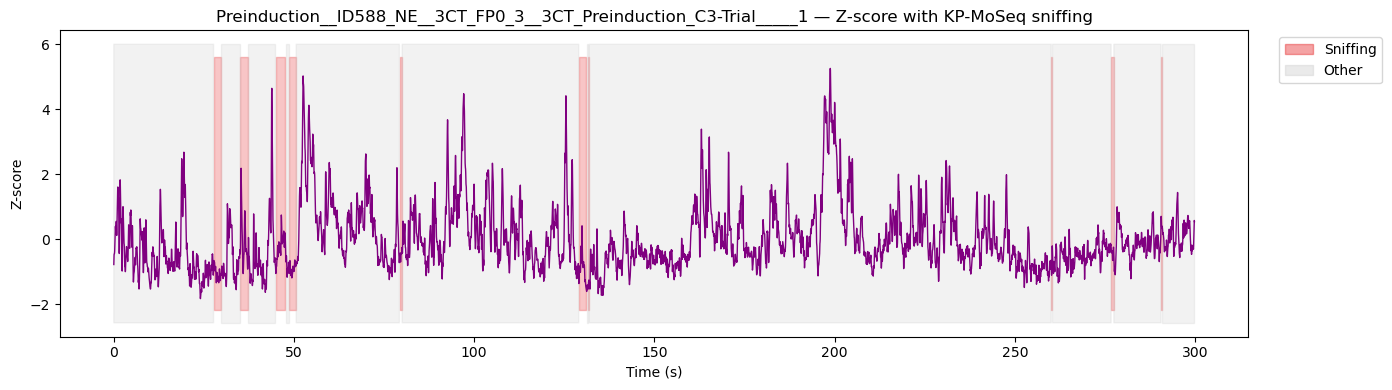

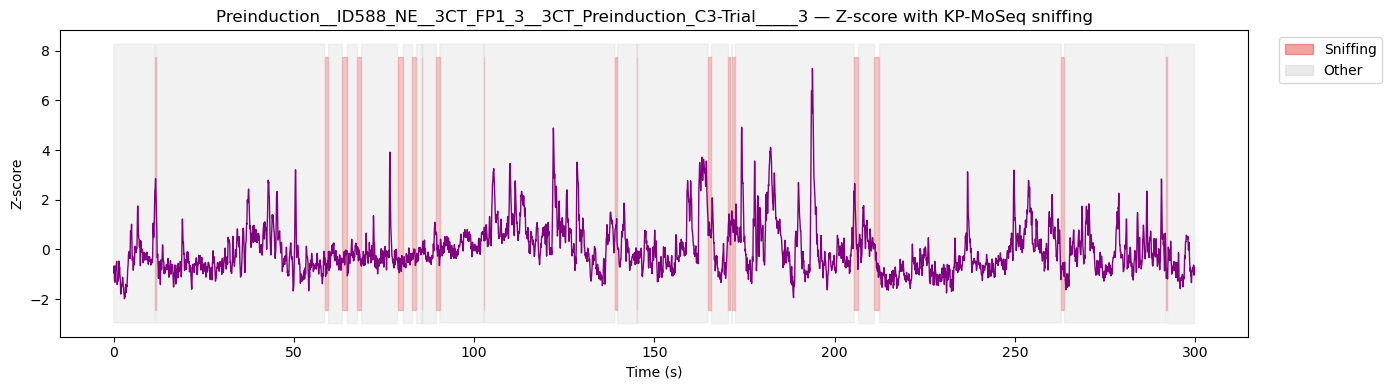

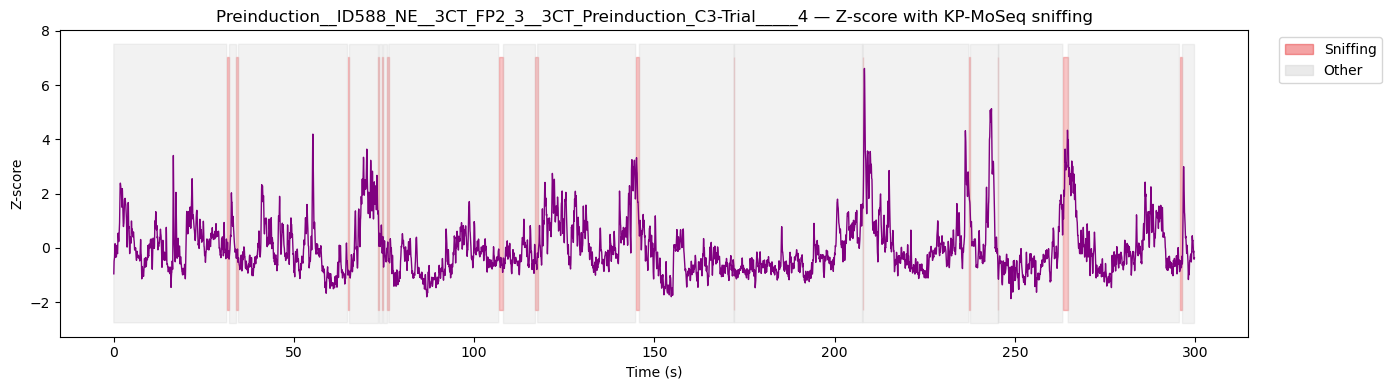

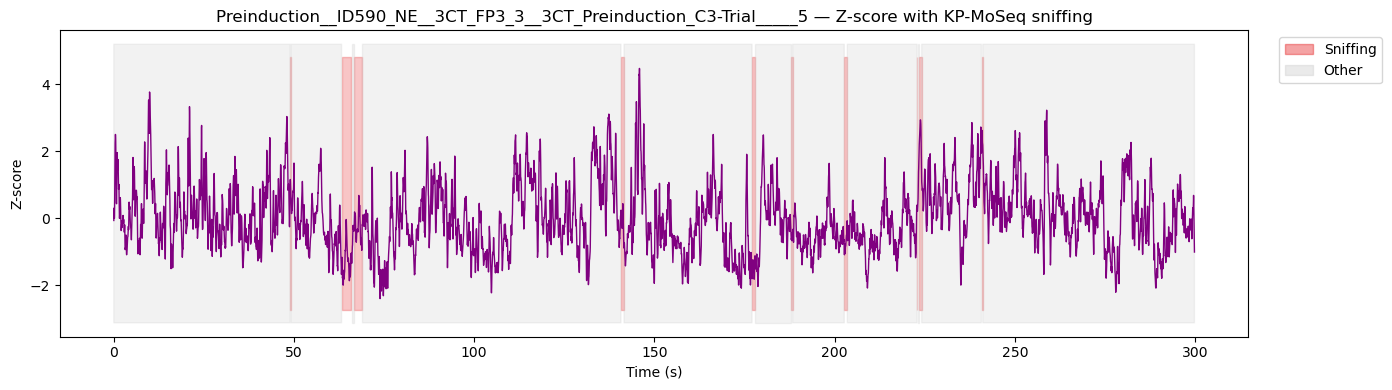

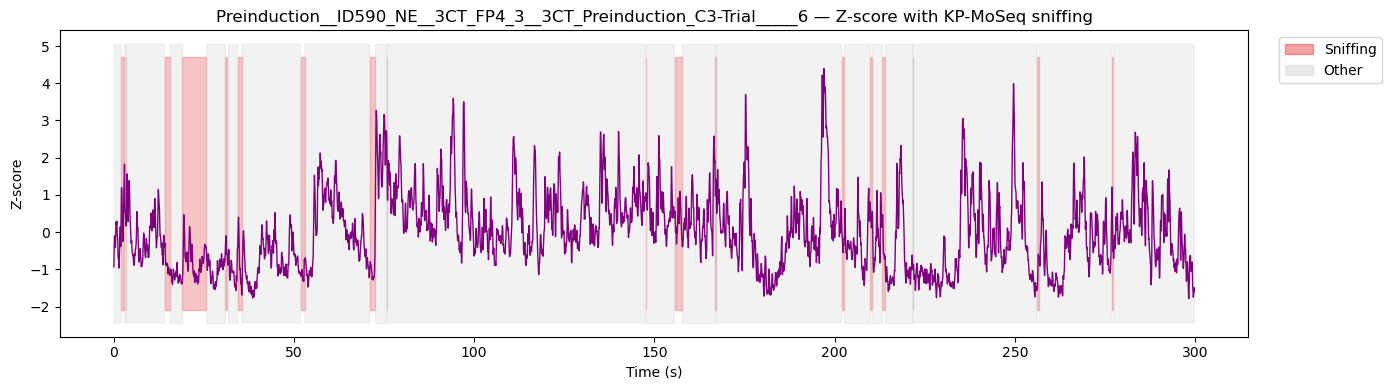

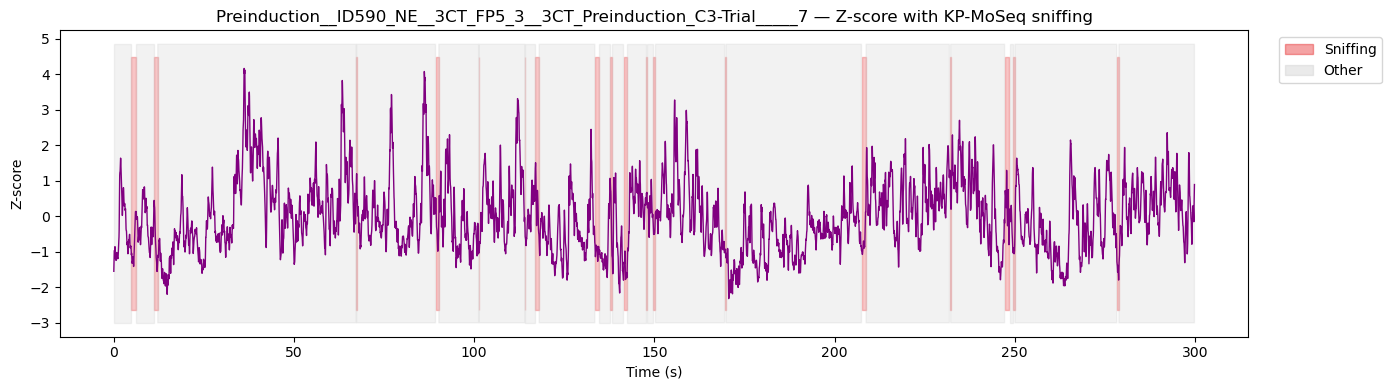

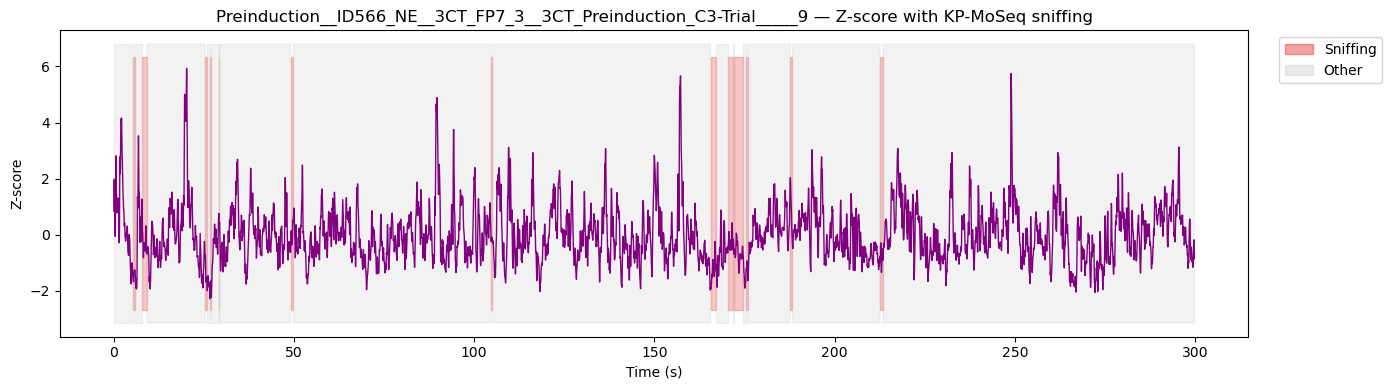

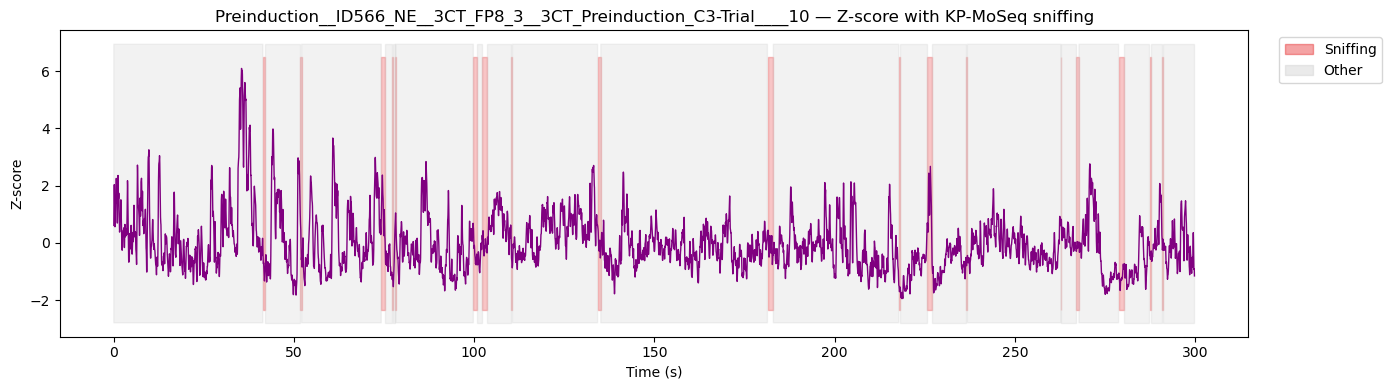

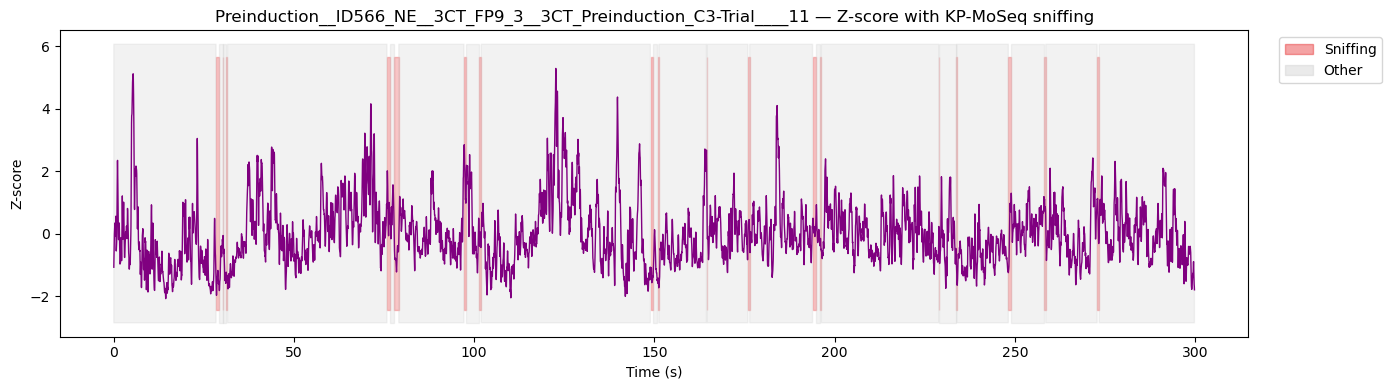

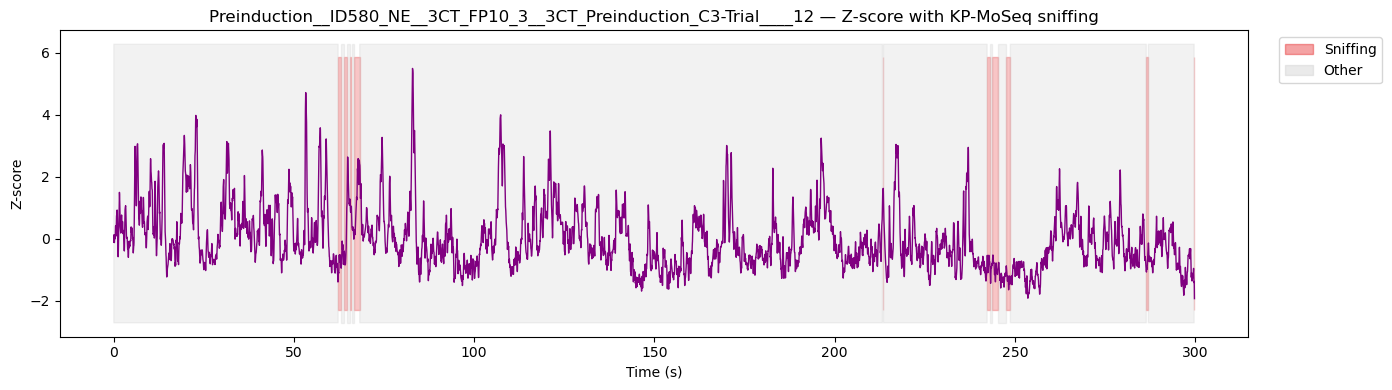

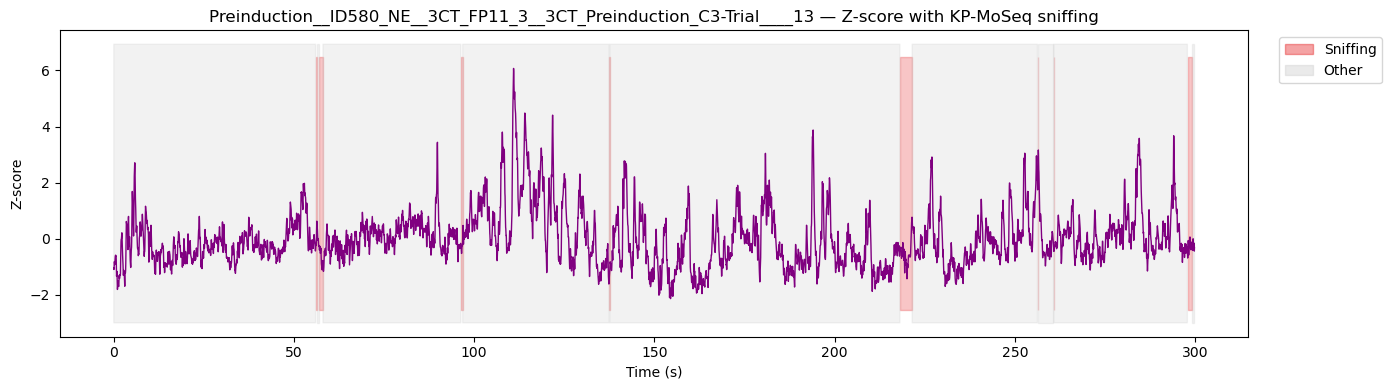

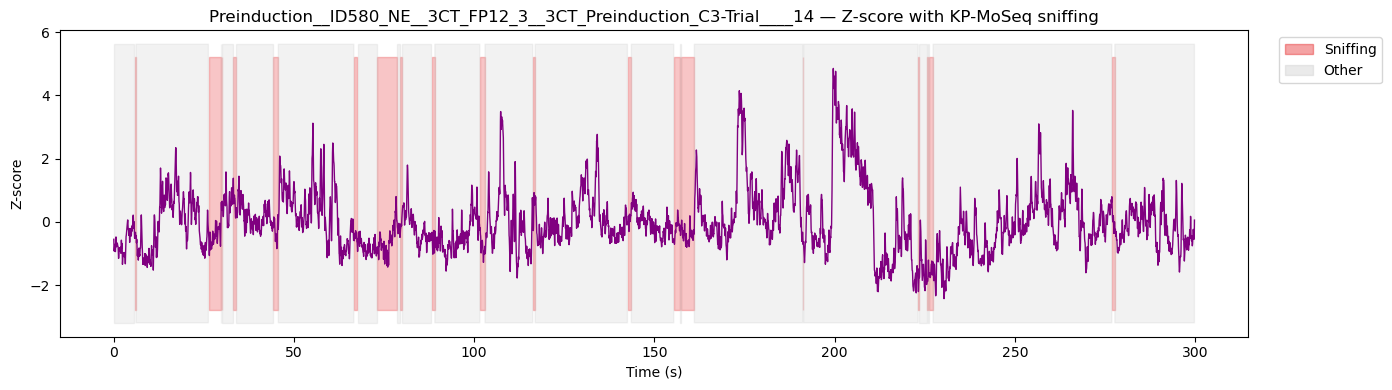

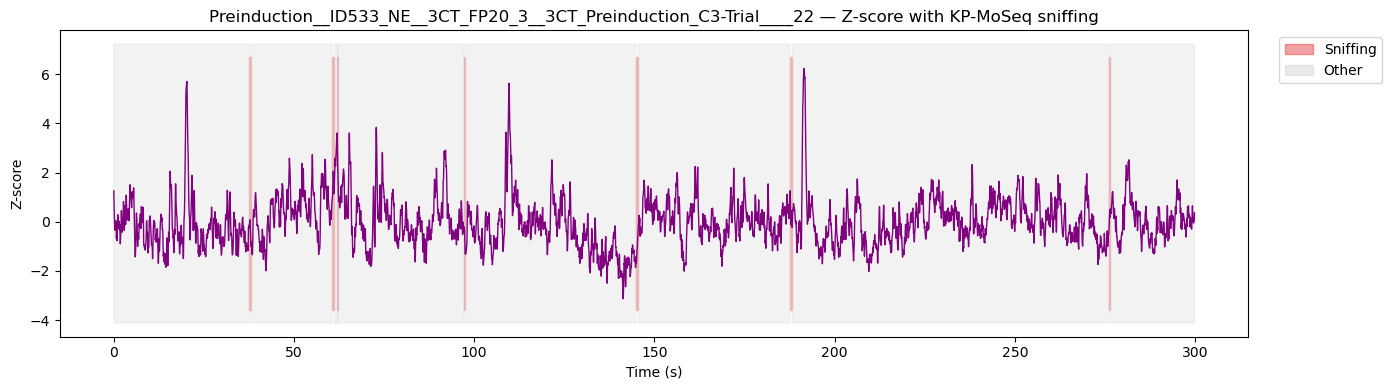

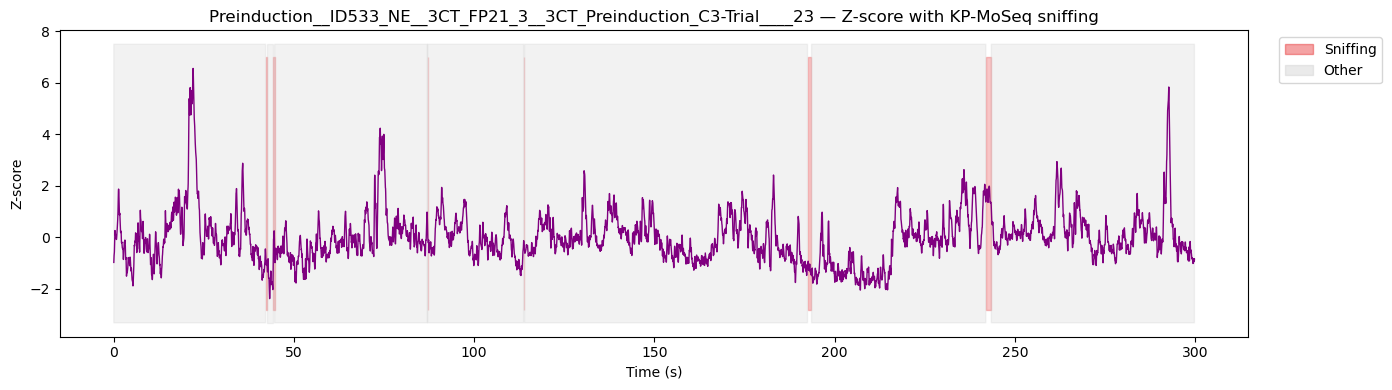

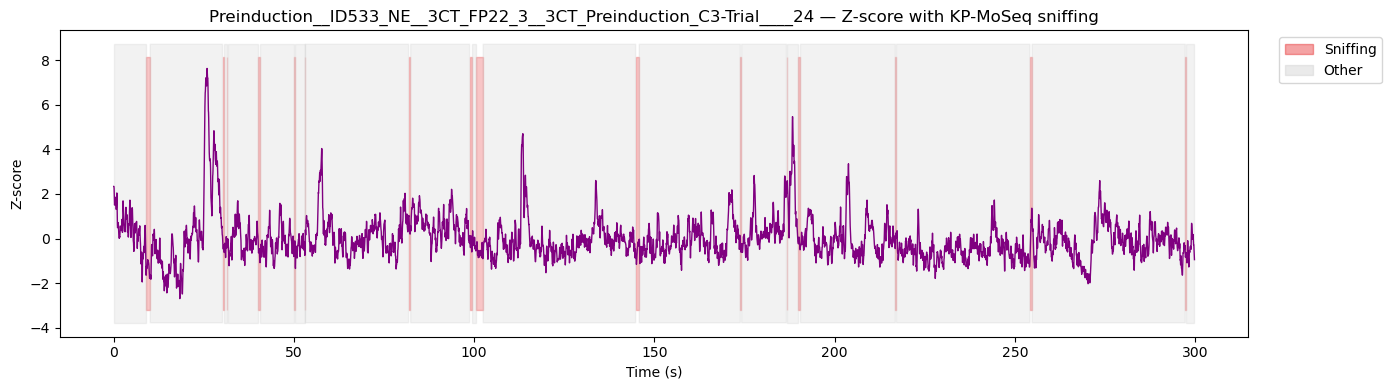

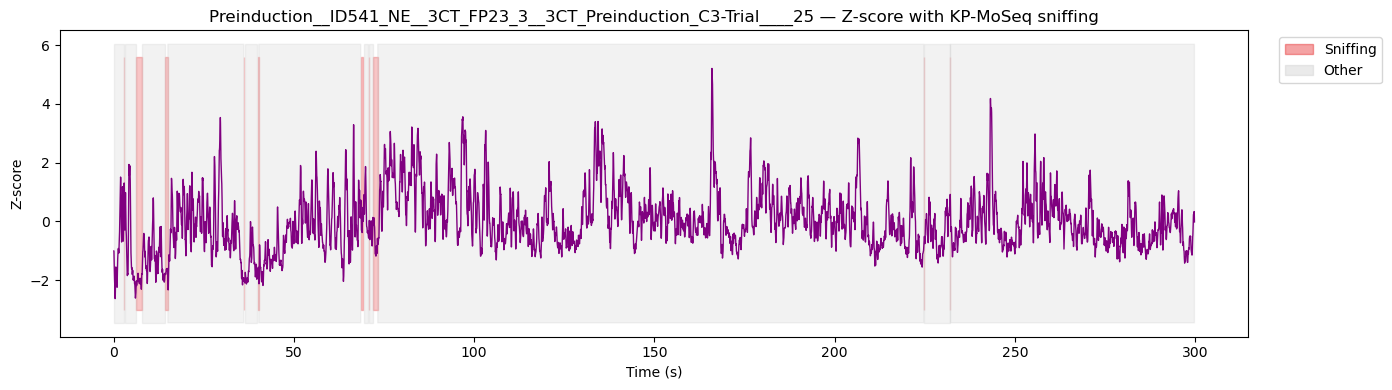

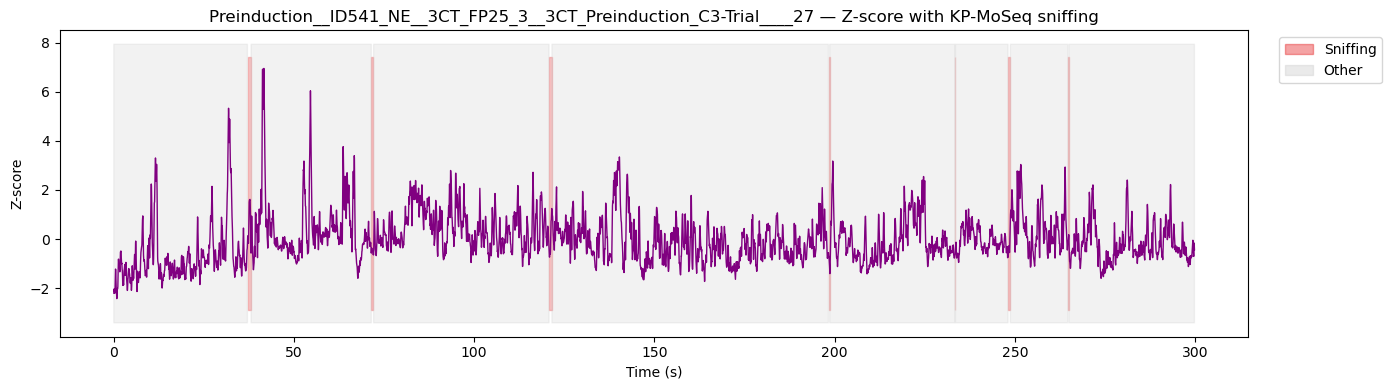

In [10]:
import matplotlib.patches as mpatches

beh_colors = {SNIFFING_LABEL: "#E41A1C", "Other": "#CCCCCC"}

def plot_zscore_with_sniffing(df, key, save_dir=None):
    time     = df["Time_video"].values
    zscore   = df["gcamp_z"].values
    behaviors = df["Behavior"].values

    fig, ax = plt.subplots(figsize=(14, 4))
    ax.plot(time, zscore, color="purple", linewidth=1)
    ax.set_ylabel("Z-score")
    ax.set_xlabel("Time (s)")
    ax.set_title(f"{key} — Z-score with KP-MoSeq sniffing")

    for beh, color in beh_colors.items():
        mask = behaviors == beh
        ax.fill_between(time, ax.get_ylim()[0], ax.get_ylim()[1],
                        where=mask, color=color, alpha=0.25, step="post")

    handles = [mpatches.Patch(color=c, alpha=0.4, label=b)
               for b, c in beh_colors.items()]
    ax.legend(handles=handles, bbox_to_anchor=(1.02, 1), loc="upper left")
    plt.tight_layout()

    if save_dir is not None:
        out = save_dir / f"{key}_zscore_sniffing.png"
        plt.savefig(out, dpi=150, bbox_inches="tight")
        plt.close()
    else:
        plt.show()

# Plot all trials
for trial_key in combined_trials:
    try:
        plot_zscore_with_sniffing(combined_trials[trial_key], trial_key)
    except Exception as e:
        print(f"[WARN] {trial_key}: {e}")


# Peri-event plots
## Single trial example

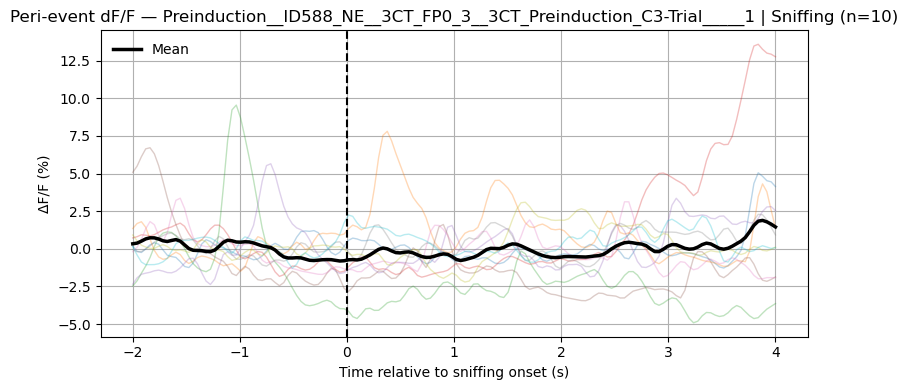

In [11]:
pre_s  = 2.0
post_s = 4.0

example_key = list(combined_trials.keys())[0]
df = combined_trials[example_key].copy()

time_vec    = df["Time_video"].values
signal_vec  = df["gcamp_dF_F"].values
behaviors   = df["Behavior"].values

fps    = 1 / np.mean(np.diff(time_vec))
pre_n  = int(pre_s  * fps)
post_n = int(post_s * fps)

mask  = (behaviors == SNIFFING_LABEL)
diffs = np.diff(np.r_[0, mask.astype(int)])
event_starts_idx = np.where(diffs == 1)[0]

segments = []
for idx in event_starts_idx:
    if idx >= pre_n and (idx + post_n) < len(signal_vec):
        seg = signal_vec[idx - pre_n: idx + post_n].copy()
        seg -= np.mean(seg[:pre_n])   # baseline subtraction
        segments.append(seg)

if segments:
    ERF      = np.column_stack(segments)
    t_window = np.linspace(-pre_s, post_s, pre_n + post_n)

    fig, ax = plt.subplots(figsize=(8, 4))
    colors = plt.cm.tab10(np.linspace(0, 1, ERF.shape[1]))
    for i, col in enumerate(colors):
        ax.plot(t_window, ERF[:, i], color=col, alpha=0.3, lw=1)
    ax.plot(t_window, ERF.mean(axis=1), color="black", lw=2.5, label="Mean")
    ax.axvline(0, color="k", linestyle="--")
    ax.set_title(f"Peri-event dF/F — {example_key} | Sniffing (n={ERF.shape[1]})")
    ax.set_xlabel("Time relative to sniffing onset (s)")
    ax.set_ylabel("ΔF/F (%)")
    ax.grid(True)
    ax.legend(frameon=False)
    plt.tight_layout()
    plt.show()
else:
    print("No valid peri-event segments for this trial.")


## Grand mean peri-event plots — Social condition

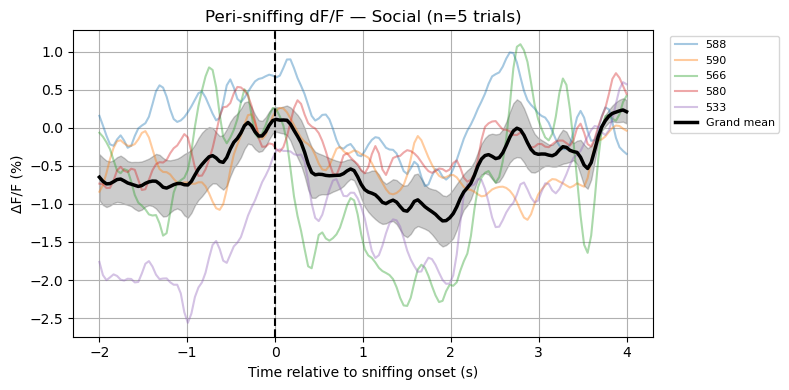

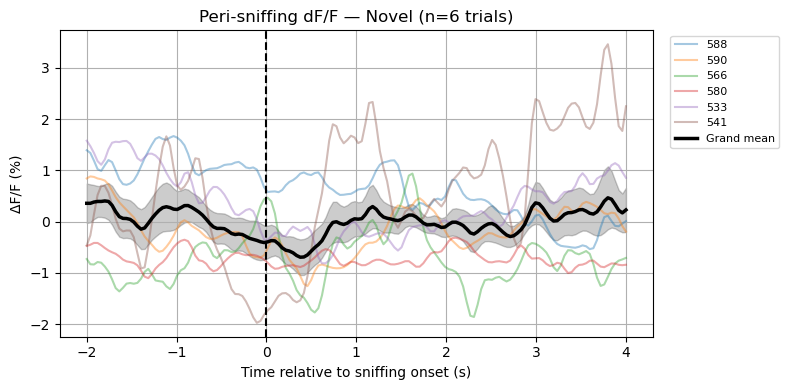

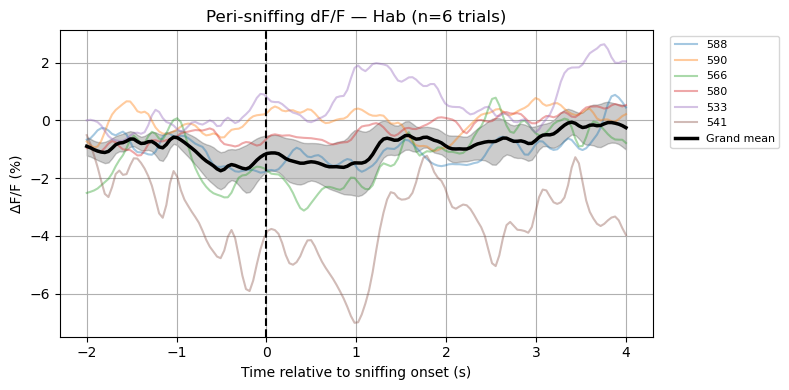

In [12]:
pre_s  = 2.0
post_s = 4.0

# Global FPS
all_dts = []
for td in combined_trials.values():
    all_dts.extend(np.diff(td["Time_video"].values))
global_fps = 1 / np.median(all_dts)
pre_n  = int(pre_s  * global_fps)
post_n = int(post_s * global_fps)
expected_len = pre_n + post_n
t_window = np.linspace(-pre_s, post_s, expected_len)

for selected_condition in ["Social", "Novel", "Hab"]:
    # Collect mouse-mean segments
    mouse_segments = []
    mouse_ids_plot = []

    for trial_key, trial_data in combined_trials.items():
        fp_info = fp_traces[trial_key]
        if fp_info.get("condition") != selected_condition:
            continue

        signal_vec  = trial_data["gcamp_dF_F"].values
        behaviors   = trial_data["Behavior"].values

        starts = np.where(np.diff(np.r_[0, (behaviors == SNIFFING_LABEL).astype(int)]) == 1)[0]
        if len(starts) == 0:
            continue

        segs = []
        for idx in starts:
            if idx >= pre_n and (idx + post_n) < len(signal_vec):
                seg = signal_vec[idx - pre_n: idx + post_n].copy()
                if len(seg) == expected_len:
                    segs.append(seg)

        if not segs:
            continue

        mouse_mean = np.mean(np.column_stack(segs), axis=1)
        mouse_segments.append(mouse_mean)
        mouse_ids_plot.append(fp_info.get("mouse_id", trial_key))

    if not mouse_segments:
        print(f"No sniffing events found for condition: {selected_condition}")
        continue

    mouse_segments = np.vstack(mouse_segments)

    fig, ax = plt.subplots(figsize=(8, 4))
    for i, seg in enumerate(mouse_segments):
        ax.plot(t_window, seg, alpha=0.4, lw=1.5, label=mouse_ids_plot[i])

    grand_mean = np.mean(mouse_segments, axis=0)
    sem        = np.std(mouse_segments, axis=0) / np.sqrt(mouse_segments.shape[0])
    ax.plot(t_window, grand_mean, color="black", lw=2.5, label="Grand mean")
    ax.fill_between(t_window, grand_mean - sem, grand_mean + sem,
                    color="black", alpha=0.2)

    ax.axvline(0, color="k", linestyle="--")
    ax.set_title(f"Peri-sniffing dF/F — {selected_condition} (n={mouse_segments.shape[0]} trials)")
    ax.set_xlabel("Time relative to sniffing onset (s)")
    ax.set_ylabel("ΔF/F (%)")
    ax.grid(True)
    ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8)
    plt.tight_layout()
    plt.show()


## Peri-event plots by week — Social and Novel


Drop report — Social | NE
  Preinduction: total=68 | dropped_pre=0 | dropped_post=1 | kept=67
  W2: total=0 | dropped_pre=0 | dropped_post=0 | kept=0
Saved: peri_event_sniffing_svgs/sniffing_Social_NE.svg


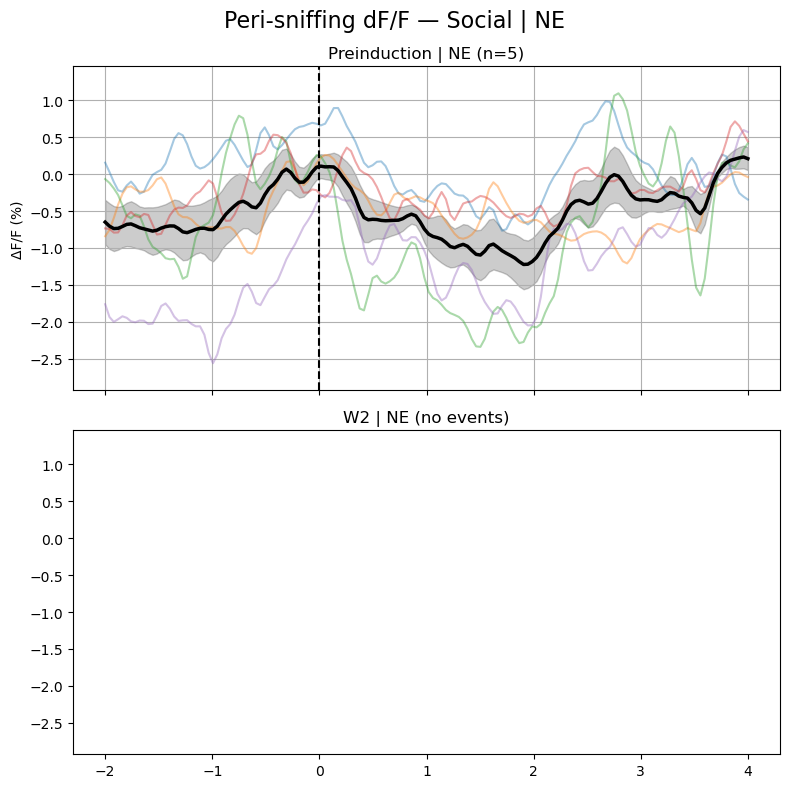


Drop report — Novel | NE
  Preinduction: total=93 | dropped_pre=0 | dropped_post=1 | kept=92
  W2: total=0 | dropped_pre=0 | dropped_post=0 | kept=0
Saved: peri_event_sniffing_svgs/sniffing_Novel_NE.svg


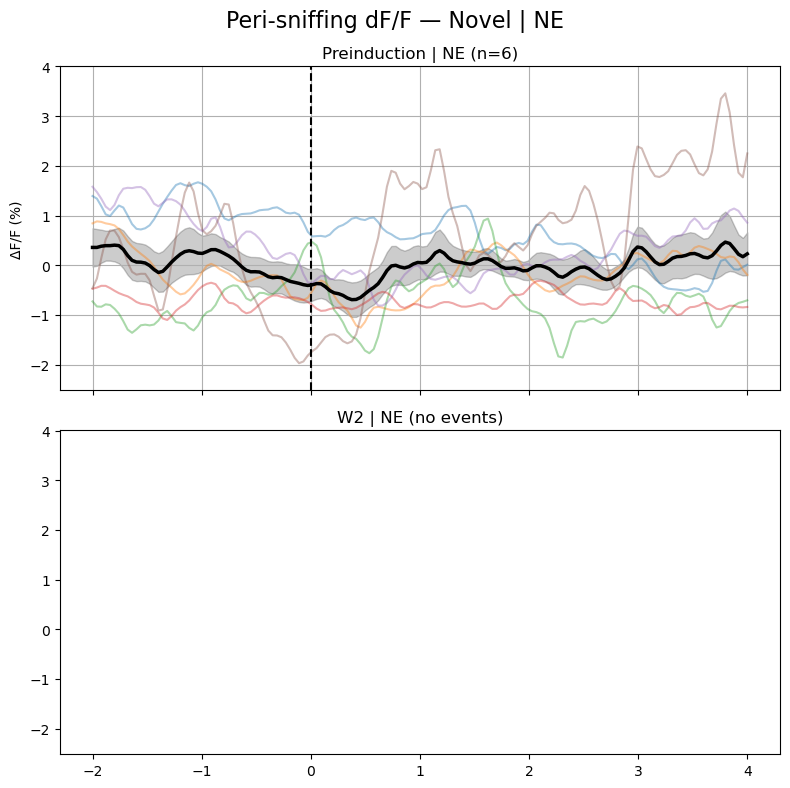

In [13]:
import os

pre_s  = 2.0
post_s = 4.0

save_figures  = True
output_dir    = "peri_event_sniffing_svgs"
os.makedirs(output_dir, exist_ok=True)

all_dts = []
for td in combined_trials.values():
    all_dts.extend(np.diff(td["Time_video"].values))
global_fps   = 1 / np.median(all_dts)
pre_n        = int(pre_s  * global_fps)
post_n       = int(post_s * global_fps)
expected_len = pre_n + post_n
t_window     = np.linspace(-pre_s, post_s, expected_len)

selected_genotype = "NE"
selected_weeks    = ["Preinduction", "W2"]

for selected_condition in ["Social", "Novel"]:

    fig, axes = plt.subplots(len(selected_weeks), 1,
                              figsize=(8, 4 * len(selected_weeks)),
                              sharex=True, sharey=True)
    if len(selected_weeks) == 1:
        axes = [axes]

    mouse_data_by_week = {}
    global_min, global_max = np.inf, -np.inf
    drop_report = []

    for week in selected_weeks:
        mouse_segments = []
        total_events = dropped_pre = dropped_post = kept = 0

        for trial_key, trial_data in combined_trials.items():
            fp_info = fp_traces[trial_key]
            if fp_info.get("condition") != selected_condition: continue
            if fp_info.get("genotype")  != selected_genotype:  continue
            if fp_info.get("week")      != week:                continue

            signal_vec = trial_data["gcamp_dF_F"].values
            behaviors  = trial_data["Behavior"].values

            starts = np.where(np.diff(np.r_[0, (behaviors == SNIFFING_LABEL).astype(int)]) == 1)[0]
            segs = []
            for idx in starts:
                total_events += 1
                if idx < pre_n:                              dropped_pre  += 1; continue
                if (idx + post_n) >= len(signal_vec):        dropped_post += 1; continue
                seg = signal_vec[idx - pre_n: idx + post_n].copy()
                if len(seg) != expected_len:                 continue
                # seg -= np.mean(seg[:pre_n])  # uncomment for baseline subtraction
                segs.append(seg)
                kept += 1

            if segs:
                mouse_segments.append(np.mean(np.column_stack(segs), axis=1))

        drop_report.append(dict(week=week, total=total_events,
                                dropped_pre=dropped_pre, dropped_post=dropped_post,
                                kept=kept))

        if mouse_segments:
            ms = np.vstack(mouse_segments)
            mouse_data_by_week[week] = ms
            global_min = min(global_min, ms.min())
            global_max = max(global_max, ms.max())
        else:
            mouse_data_by_week[week] = None

    print(f"\nDrop report — {selected_condition} | {selected_genotype}")
    for r in drop_report:
        print(f"  {r['week']}: total={r['total']} | dropped_pre={r['dropped_pre']} "
              f"| dropped_post={r['dropped_post']} | kept={r['kept']}")

    if global_min == np.inf:
        plt.close(fig)
        continue

    y_pad = 0.1 * (global_max - global_min + 1e-9)
    y_min, y_max = global_min - y_pad, global_max + y_pad

    for r, week in enumerate(selected_weeks):
        ax = axes[r]
        ms = mouse_data_by_week.get(week)
        if ms is None:
            ax.set_title(f"{week} | {selected_genotype} (no events)")
            continue

        for seg in ms:
            ax.plot(t_window, seg, alpha=0.4, lw=1.5)
        grand_mean = np.mean(ms, axis=0)
        sem        = np.std(ms, axis=0) / np.sqrt(ms.shape[0])
        ax.plot(t_window, grand_mean, color="black", lw=2.5)
        ax.fill_between(t_window, grand_mean - sem, grand_mean + sem,
                        color="black", alpha=0.2)
        ax.axvline(0, color="k", linestyle="--")
        ax.set_title(f"{week} | {selected_genotype} (n={ms.shape[0]})")
        ax.set_ylim(y_min, y_max)
        ax.grid(True)
        if r == len(selected_weeks) - 1:
            ax.set_xlabel("Time (s)")
        ax.set_ylabel("ΔF/F (%)")

    fig.suptitle(f"Peri-sniffing dF/F — {selected_condition} | {selected_genotype}", fontsize=16)
    plt.tight_layout()

    if save_figures:
        filepath = os.path.join(output_dir, f"sniffing_{selected_condition}_{selected_genotype}.svg")
        fig.savefig(filepath, format="svg", bbox_inches="tight")
        print(f"Saved: {filepath}")

    plt.show()
    plt.close(fig)


# Mean dF/F across entire sniffing period

In [14]:
mean_rows = []

for trial_key, df in combined_trials.items():
    fp_info   = fp_traces[trial_key]
    mouse_id  = fp_info.get("mouse_id")
    genotype  = fp_info.get("genotype")
    condition = fp_info.get("condition")
    week      = fp_info.get("week")

    beh = df["Behavior"].values
    dff = df["gcamp_dF_F"].values

    for b in np.unique(beh):
        mask = beh == b
        if mask.sum() == 0:
            continue
        mean_rows.append({
            "mouse_id":  mouse_id,
            "genotype":  genotype,
            "condition": condition,
            "week":      week,
            "behavior":  b,
            "mean_dFF":  np.nanmean(dff[mask]),
            "n_points":  int(mask.sum()),
        })

mean_summary_df = pd.DataFrame(mean_rows)
print("mean_summary_df shape:", mean_summary_df.shape)
print(mean_summary_df.head(10))


mean_summary_df shape: (34, 7)
  mouse_id genotype condition          week  behavior  mean_dFF  n_points
0      588       NE       Hab  Preinduction     Other  0.066586      7158
1      588       NE       Hab  Preinduction  Sniffing -1.406372       339
2      588       NE    Social  Preinduction     Other  0.000336      7142
3      588       NE    Social  Preinduction  Sniffing -0.006761       355
4      588       NE     Novel  Preinduction     Other -0.035480      7283
5      588       NE     Novel  Preinduction  Sniffing  1.207546       214
6      590       NE       Hab  Preinduction     Other  0.027527      7267
7      590       NE       Hab  Preinduction  Sniffing -0.869496       230
8      590       NE    Social  Preinduction     Other  0.082102      7002
9      590       NE    Social  Preinduction  Sniffing -1.161372       495


## Export LMER-ready CSV (mean dFF across full sniffing period)

In [15]:
def export_lmer_ready_csv(df, condition_filter=None, genotype_filter=None, filename="lmer_ready.csv"):
    data = df.copy()
    if condition_filter is not None:
        data = data[data["condition"] == condition_filter]
    if genotype_filter is not None:
        data = data[data["genotype"] == genotype_filter]
    data = data[data["behavior"] == SNIFFING_LABEL]   # sniffing only

    lmer_df = (
        data.groupby(["mouse_id", "week", "behavior"], as_index=False)["mean_dFF"]
        .mean().dropna()
    )
    week_order = ["Preinduction", "W1", "W2", "W3"]
    lmer_df["week"] = pd.Categorical(lmer_df["week"], categories=week_order, ordered=True)
    lmer_df = lmer_df.sort_values(["mouse_id", "week"]).reset_index(drop=True)

    save_dir = os.path.join("R_processing", "mean_dff_sniffing_full_behaviour")
    os.makedirs(save_dir, exist_ok=True)
    save_path = os.path.join(save_dir, filename)
    lmer_df.to_csv(save_path, index=False)
    print(f"✅ Saved: {save_path}  (shape: {lmer_df.shape})")
    return lmer_df

export_lmer_ready_csv(mean_summary_df, condition_filter="Social",  genotype_filter="NE",
                      filename="social_NE_sniffing_lmer_ready.csv")
export_lmer_ready_csv(mean_summary_df, condition_filter="Novel",   genotype_filter="NE",
                      filename="novel_NE_sniffing_lmer_ready.csv")


✅ Saved: R_processing/mean_dff_sniffing_full_behaviour/social_NE_sniffing_lmer_ready.csv  (shape: (5, 4))
✅ Saved: R_processing/mean_dff_sniffing_full_behaviour/novel_NE_sniffing_lmer_ready.csv  (shape: (6, 4))


,mouse_id,week,behavior,mean_dFF
0,533,Preinduction,Sniffing,-1.070906
1,541,Preinduction,Sniffing,-0.132914
2,566,Preinduction,Sniffing,-0.513555
3,580,Preinduction,Sniffing,-0.836127
4,588,Preinduction,Sniffing,1.207546
5,590,Preinduction,Sniffing,-1.005910


# Post-onset mean dF/F (2 s after sniffing onset)
## WITHOUT baseline subtraction

In [16]:
post_window_s = (0, 2)

all_dts = []
for td in combined_trials.values():
    if "Time_video" in td.columns:
        all_dts.extend(np.diff(td["Time_video"].values))
global_fps = 1 / np.median(all_dts)
print("Global FPS:", global_fps)

summary_post_mean = []

for trial_key, trial_data in combined_trials.items():
    fp_info   = fp_traces.get(trial_key, {})
    week      = fp_info.get("week")
    condition = fp_info.get("condition")
    genotype  = fp_info.get("genotype")
    mouse_id  = fp_info.get("mouse_id", trial_key)

    if genotype != "NE":
        continue
    if "gcamp_dF_F" not in trial_data.columns:
        continue

    signal    = trial_data["gcamp_dF_F"].values
    behaviors = trial_data["Behavior"].values

    starts = np.where(np.diff(np.r_[0, (behaviors == SNIFFING_LABEL).astype(int)]) == 1)[0]
    if len(starts) == 0:
        continue

    post_means = []
    for idx in starts:
        ps = idx + int(post_window_s[0] * global_fps)
        pe = idx + int(post_window_s[1] * global_fps)
        if pe >= len(signal) or ps < 0:
            continue
        seg = signal[ps:pe]
        if len(seg) == 0:
            continue
        post_means.append(np.nanmean(seg))

    if not post_means:
        continue

    summary_post_mean.append({
        "mouse_id": mouse_id, "genotype": genotype, "condition": condition,
        "week": week, "behavior": SNIFFING_LABEL,
        "mean_dFF": np.mean(post_means), "n_events": len(post_means)
    })

post_mean_df = pd.DataFrame(summary_post_mean)
print("Shape:", post_mean_df.shape)
print(post_mean_df.head())

# Filter mice with at least 2 weeks
valid_mice = (post_mean_df.groupby("mouse_id")["week"].nunique()
              .loc[lambda x: x >= 2].index)
post_mean_df = post_mean_df[post_mean_df["mouse_id"].isin(valid_mice)]

save_dir = os.path.join("R_processing", "mean_dff_sniffing_2s_post")
os.makedirs(save_dir, exist_ok=True)
for condition, cond_df in post_mean_df.groupby("condition"):
    fp = os.path.join(save_dir, f"NE_{condition}_sniffing_post2s_mean_dff.csv")
    cond_df.to_csv(fp, index=False)
    print(f"✅ Saved: {fp}  ({cond_df.shape})")


Global FPS: 25.000000000022737
Shape: (17, 7)
  mouse_id genotype condition          week  behavior  mean_dFF  n_events
0      588       NE       Hab  Preinduction  Sniffing -1.314569        10
1      588       NE    Social  Preinduction  Sniffing -0.119502        18
2      588       NE     Novel  Preinduction  Sniffing  0.692238        15
3      590       NE       Hab  Preinduction  Sniffing -0.059428        10
4      590       NE    Social  Preinduction  Sniffing -0.378906        18


## WITH baseline subtraction (2 s pre-onset baseline)

In [17]:
pre_window_s  = 2.0
post_window_s = (0, 2)

all_dts = []
for td in combined_trials.values():
    if "Time_video" in td.columns:
        all_dts.extend(np.diff(td["Time_video"].values))
global_fps = 1 / np.median(all_dts)
pre_n = int(pre_window_s * global_fps)
print("Global FPS:", global_fps)

summary_post_mean_bl = []

for trial_key, trial_data in combined_trials.items():
    fp_info   = fp_traces.get(trial_key, {})
    week      = fp_info.get("week")
    condition = fp_info.get("condition")
    genotype  = fp_info.get("genotype")
    mouse_id  = fp_info.get("mouse_id", trial_key)

    if genotype != "NE":
        continue
    if "gcamp_dF_F" not in trial_data.columns:
        continue

    signal    = trial_data["gcamp_dF_F"].values
    behaviors = trial_data["Behavior"].values

    starts = np.where(np.diff(np.r_[0, (behaviors == SNIFFING_LABEL).astype(int)]) == 1)[0]
    if len(starts) == 0:
        continue

    post_means = []
    for idx in starts:
        pre_start  = idx - pre_n
        post_start = idx + int(post_window_s[0] * global_fps)
        post_end   = idx + int(post_window_s[1] * global_fps)
        if pre_start < 0 or post_end >= len(signal):
            continue
        pre_seg  = signal[pre_start:idx]
        post_seg = signal[post_start:post_end]
        if len(pre_seg) == 0 or len(post_seg) == 0:
            continue
        baseline = np.nanmean(pre_seg)
        post_means.append(np.nanmean(post_seg) - baseline)

    if not post_means:
        continue

    summary_post_mean_bl.append({
        "mouse_id": mouse_id, "genotype": genotype, "condition": condition,
        "week": week, "behavior": SNIFFING_LABEL,
        "mean_dFF": np.mean(post_means), "n_events": len(post_means)
    })

post_mean_bl_df = pd.DataFrame(summary_post_mean_bl)
print("Shape:", post_mean_bl_df.shape)

valid_mice = (post_mean_bl_df.groupby("mouse_id")["week"].nunique()
              .loc[lambda x: x >= 2].index)
post_mean_bl_df = post_mean_bl_df[post_mean_bl_df["mouse_id"].isin(valid_mice)]

save_dir = os.path.join("R_processing", "mean_dff_sniffing_2s_post")
os.makedirs(save_dir, exist_ok=True)
for condition, cond_df in post_mean_bl_df.groupby("condition"):
    fp = os.path.join(save_dir, f"NE_{condition}_sniffing_post2s_mean_dff_baseline_subtraction.csv")
    cond_df.to_csv(fp, index=False)
    print(f"✅ Saved: {fp}  ({cond_df.shape})")


Global FPS: 25.000000000022737
Shape: (17, 7)


# Pre/post sniffing onset — mean dF/F (-2 to 0 s vs 0 to 2 s)

In [18]:
pre_window_s  = (-2, 0)
post_window_s = (0, 2)

all_dts = []
for td in combined_trials.values():
    if "Time_video" in td.columns:
        all_dts.extend(np.diff(td["Time_video"].values))
global_fps = 1 / np.median(all_dts)

summary_prepost = []

for trial_key, trial_data in combined_trials.items():
    fp_info   = fp_traces.get(trial_key, {})
    mouse_id  = fp_info.get("mouse_id", trial_key)
    genotype  = fp_info.get("genotype")
    condition = fp_info.get("condition")
    week      = fp_info.get("week")

    if "gcamp_dF_F" not in trial_data.columns:
        continue

    signal    = trial_data["gcamp_dF_F"].values
    behaviors = trial_data["Behavior"].values

    starts = np.where(np.diff(np.r_[0, (behaviors == SNIFFING_LABEL).astype(int)]) == 1)[0]

    pre_means, post_means = [], []

    for idx in starts:
        pre_start  = idx + int(pre_window_s[0]  * global_fps)
        pre_end    = idx + int(pre_window_s[1]  * global_fps)
        post_start = idx + int(post_window_s[0] * global_fps)
        post_end   = idx + int(post_window_s[1] * global_fps)

        if pre_start < 0 or post_end >= len(signal):
            continue

        pre_seg  = signal[pre_start:pre_end]
        post_seg = signal[post_start:post_end]

        if len(pre_seg) == 0 or len(post_seg) == 0:
            continue

        pre_means.append(np.nanmean(pre_seg))
        post_means.append(np.nanmean(post_seg))

    if not pre_means:
        continue

    summary_prepost.append({
        "mouse_id":     mouse_id,
        "genotype":     genotype,
        "condition":    condition,
        "week":         week,
        "behavior":     SNIFFING_LABEL,
        "pre_mean_dFF": np.mean(pre_means),
        "post_mean_dFF": np.mean(post_means),
        "n_events":     len(pre_means)
    })

prepost_df = pd.DataFrame(summary_prepost)
print("Shape:", prepost_df.shape)
print(prepost_df.head())


Shape: (17, 8)
  mouse_id genotype condition          week  behavior  pre_mean_dFF  \
0      588       NE       Hab  Preinduction  Sniffing     -1.002550   
1      588       NE    Social  Preinduction  Sniffing      0.255171   
2      588       NE     Novel  Preinduction  Sniffing      1.154119   
3      590       NE       Hab  Preinduction  Sniffing     -0.165790   
4      590       NE    Social  Preinduction  Sniffing     -0.429455   

   post_mean_dFF  n_events  
0      -1.314569        10  
1      -0.119502        18  
2       0.692238        15  
3      -0.059428        10  
4      -0.378906        18  


## Pre/post plot with paired statistics

✅ CSV saved: R_processing/sniffing_pre_post_analysis/sniffing_prepost_NE_Social.csv

Stats — Social | NE
  genotype          week    t_stat   p_value  cohens_d  p_corrected
0       NE  Preinduction -0.707483  0.518308 -0.316396     0.518308


/Users/annastuckert/anaconda3/lib/python3.11/site-packages/seaborn/axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)
/Users/annastuckert/anaconda3/lib/python3.11/site-packages/seaborn/categorical.py:166: FutureWarning: Setting a gradient palette using color= is deprecated and will be removed in version 0.13. Set `palette='dark:#1f77b4'` for same effect.
  warnings.warn(msg, FutureWarning)
/Users/annastuckert/anaconda3/lib/python3.11/site-packages/seaborn/axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)
/var/folders/3y/jmv30wb16ss901m1yrdysjh80000gq/T/ipykernel_94572/1318858142.py:83: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


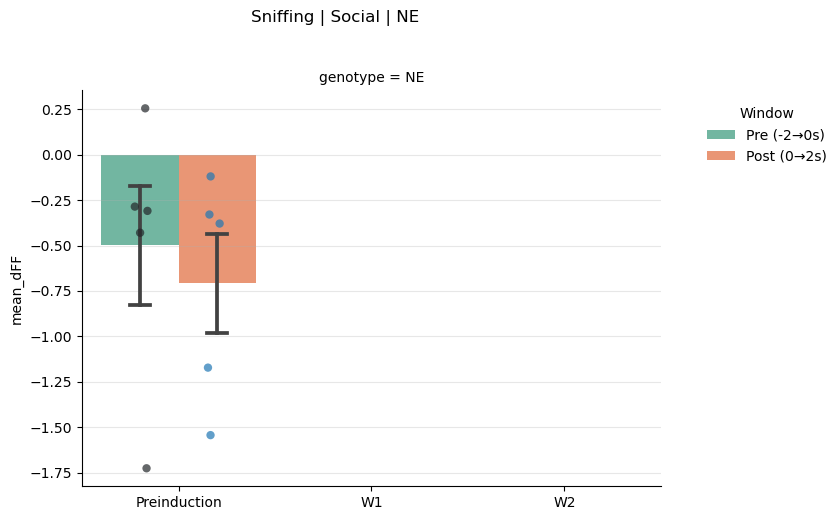

✅ Plot saved: R_processing/sniffing_pre_post_analysis/plots/sniffing_prepost_NE_Social.svg


In [19]:
import seaborn as sns
from scipy.stats import ttest_1samp
from statsmodels.stats.multitest import multipletests

def plot_mouse_prepost_sniffing(df, pre_col, post_col, value_name="mean_dFF",
                                 condition_filter=None, genotype_filter=None):
    data = df.copy()
    if condition_filter is not None:
        data = data[data["condition"] == condition_filter]
    if genotype_filter is not None:
        data = data[data["genotype"] == genotype_filter]
    data = data[data["behavior"] == SNIFFING_LABEL]

    if data.empty:
        print("[WARN] No data to plot")
        return

    save_dir = os.path.join("R_processing", "sniffing_pre_post_analysis")
    os.makedirs(save_dir, exist_ok=True)
    csv_name = f"sniffing_prepost_{genotype_filter or 'all'}_{condition_filter or 'all'}.csv"
    data.to_csv(os.path.join(save_dir, csv_name), index=False)
    print(f"✅ CSV saved: {os.path.join(save_dir, csv_name)}")

    data = data[data["week"] != "W3"]
    week_order = ["Preinduction", "W1", "W2"]
    data["week"] = pd.Categorical(data["week"], categories=week_order, ordered=True)

    # ---- stats ----
    stats_results = []
    for (genotype, week), grp in data.groupby(["genotype", "week"]):
        diff = (grp[post_col] - grp[pre_col]).dropna()
        if len(diff) < 2:
            continue
        stat, p = ttest_1samp(diff, 0)
        cohens_d = diff.mean() / diff.std(ddof=1) if diff.std(ddof=1) != 0 else np.nan
        stats_results.append({"genotype": genotype, "week": week,
                               "t_stat": stat, "p_value": p, "cohens_d": cohens_d})

    stats_df = pd.DataFrame(stats_results)
    if not stats_df.empty:
        stats_df["p_corrected"] = multipletests(stats_df["p_value"], method="bonferroni")[1]
    print(f"\nStats — {condition_filter or 'all'} | {genotype_filter or 'all'}")
    print(stats_df)

    # ---- plot ----
    long_data = data.melt(
        id_vars=["mouse_id", "genotype", "week"],
        value_vars=[pre_col, post_col],
        var_name="window", value_name=value_name
    ).assign(window=lambda d: d["window"].map({pre_col: "Pre (-2→0s)", post_col: "Post (0→2s)"}))

    g = sns.FacetGrid(long_data, col="genotype", height=5, aspect=1.1, sharey=True)
    g.map_dataframe(sns.barplot, x="week", y=value_name, hue="window",
                    palette="Set2", errorbar="se", capsize=0.1)
    g.map_dataframe(sns.stripplot, x="week", y=value_name, hue="window",
                    dodge=True, size=6, alpha=0.7)
    if g._legend:
        g._legend.remove()
    g.add_legend(title="Window")
    g._legend.set_bbox_to_anchor((1.02, 0.85))
    g._legend._loc = 2
    g.fig.suptitle(f"Sniffing | {condition_filter or 'all'} | {genotype_filter or 'all'}", y=1.03)

    # significance stars
    for ax in g.axes.flatten():
        y_max = ax.get_ylim()[1]
        for i, week in enumerate(week_order):
            row = stats_df[stats_df["week"] == week]
            if row.empty: continue
            p = row["p_corrected"].values[0]
            if   p < 0.001: text = "***"
            elif p < 0.01:  text = "**"
            elif p < 0.05:  text = "*"
            else: continue
            ax.text(i, y_max * 1.05, text, ha="center", va="bottom", fontsize=12)
        ax.grid(axis="y", alpha=0.3)
        ax.set_xlabel("")

    plot_dir = os.path.join("R_processing", "sniffing_pre_post_analysis", "plots")
    os.makedirs(plot_dir, exist_ok=True)
    plot_path = os.path.join(plot_dir,
        f"sniffing_prepost_{genotype_filter or 'all'}_{condition_filter or 'all'}.svg")
    plt.tight_layout()
    plt.savefig(plot_path, format="svg", bbox_inches="tight")
    plt.show()
    print(f"✅ Plot saved: {plot_path}")


plot_mouse_prepost_sniffing(prepost_df, pre_col="pre_mean_dFF", post_col="post_mean_dFF",
                             value_name="mean_dFF", condition_filter="Social", genotype_filter="NE")


✅ CSV saved: R_processing/sniffing_pre_post_analysis/sniffing_prepost_NE_Novel.csv

Stats — Novel | NE
  genotype          week    t_stat   p_value  cohens_d  p_corrected
0       NE  Preinduction -0.843702  0.437327  -0.34444     0.437327


/Users/annastuckert/anaconda3/lib/python3.11/site-packages/seaborn/axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)
/Users/annastuckert/anaconda3/lib/python3.11/site-packages/seaborn/categorical.py:166: FutureWarning: Setting a gradient palette using color= is deprecated and will be removed in version 0.13. Set `palette='dark:#1f77b4'` for same effect.
  warnings.warn(msg, FutureWarning)
/Users/annastuckert/anaconda3/lib/python3.11/site-packages/seaborn/axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)
/var/folders/3y/jmv30wb16ss901m1yrdysjh80000gq/T/ipykernel_94572/1318858142.py:83: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


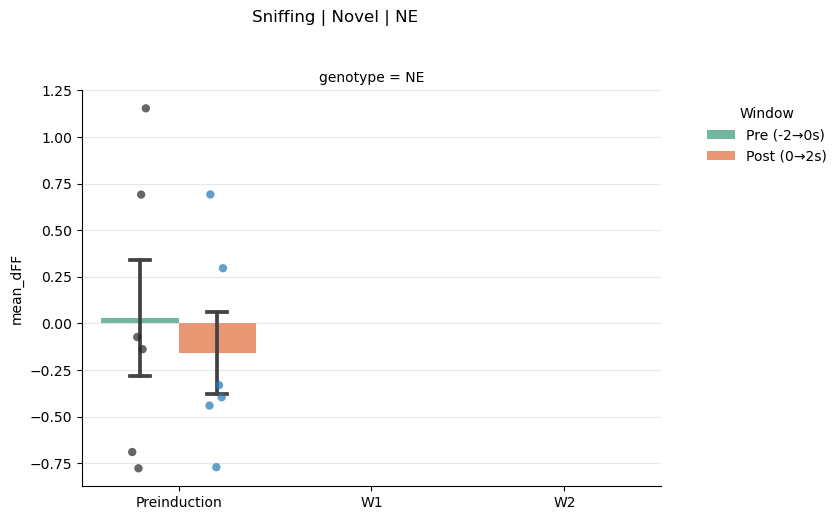

✅ Plot saved: R_processing/sniffing_pre_post_analysis/plots/sniffing_prepost_NE_Novel.svg


In [20]:
plot_mouse_prepost_sniffing(prepost_df, pre_col="pre_mean_dFF", post_col="post_mean_dFF",
                             value_name="mean_dFF", condition_filter="Novel", genotype_filter="NE")


# Sniffing bout duration export

In [21]:
rows = []

for trial_key, trial_data in combined_trials.items():
    fp_info   = fp_traces.get(trial_key, {})
    week      = fp_info.get("week")
    mouse_id  = fp_info.get("mouse_id", trial_key)
    condition = fp_info.get("condition")

    if "Behavior" not in trial_data.columns or "Time_video" not in trial_data.columns:
        continue

    behaviors = trial_data["Behavior"].values
    time_vec  = trial_data["Time_video"].values
    fps_local = 1 / np.median(np.diff(time_vec))

    mask  = (behaviors == SNIFFING_LABEL).astype(int)
    diffs = np.diff(np.r_[0, mask, 0])
    starts_b = np.where(diffs ==  1)[0]
    ends_b   = np.where(diffs == -1)[0]

    for s, e in zip(starts_b, ends_b):
        duration_s = (e - s) / fps_local
        if duration_s <= 0:
            continue
        rows.append({"week": week, "mouse_id": mouse_id, "condition": condition,
                     "behavior": SNIFFING_LABEL, "duration_s": duration_s})

df_bouts = pd.DataFrame(rows).dropna(subset=["duration_s"])
df_bouts = df_bouts[df_bouts["duration_s"] > 0]

print("Final shape:", df_bouts.shape)
print(df_bouts.head())

save_dir = os.path.join("R_processing", "sniffing_bouts")
os.makedirs(save_dir, exist_ok=True)
save_path = os.path.join(save_dir, "sniffing_bout_durations_by_condition.csv")
df_bouts.to_csv(save_path, index=False)
print(f"✅ Saved: {save_path}")


Final shape: (221, 5)
           week mouse_id condition  behavior  duration_s
0  Preinduction      588       Hab  Sniffing        2.04
1  Preinduction      588       Hab  Sniffing        2.24
2  Preinduction      588       Hab  Sniffing        2.76
3  Preinduction      588       Hab  Sniffing        1.88
4  Preinduction      588       Hab  Sniffing        0.72
✅ Saved: R_processing/sniffing_bouts/sniffing_bout_durations_by_condition.csv
